### Training script BERT 

Why BERT? 
LLMs are overkill for this problem. 
BERT is more efficient. 
Based on huggingface tutorial. 

### Import necessary packages & load data 

In [1]:
from datasets import load_from_disk
import datasets 
from transformers import AutoTokenizer 
import sys
sys.path.append("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu")
from data.CyberMetric import CyberMetric_evaluator
from openai import OpenAI 
import re
import evaluate
import numpy as np
import torch 
#!pip install nlpaug
from transformers import Trainer 
from torch import nn 
num_classes = 9
datasets.disable_caching()

KAs = {"0": "miscellaneous (this includes Computer Science, Business and Law, Communication and Networking, Information Technology, Cyberspace Practice, Pedagogy, and Intelligence)",
           "1": "data security", 
           "2": "software security",
           "3": "component security", 
           "4": "connection security", 
           "5": "system security", 
           "6": "human security", 
           "7": "organizational security",
           "8": "societal security"}

/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


### Load functions

In [2]:
from sklearn.utils.class_weight import compute_class_weight 
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
from sklearn.model_selection import StratifiedKFold, KFold
from transformers import set_seed 
import copy
set_seed(42)

def clean_text(text): 
    special_chars = r'[\"\[\]\',]'
    cleaned_text = re.sub(special_chars, '', text)
    # replace - or _ with space 
    special_chars = r'[\_\-]'
    cleaned_text2 = re.sub(special_chars,' ', cleaned_text)
    return cleaned_text2 

clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])

def sigmoid(x):
   return 1/(1 + np.exp(-x))

def compute_metrics(eval_pred):
   predictions, labels = eval_pred
   predictions = sigmoid(predictions)
   predictions = (predictions > 0.5).astype(int).reshape(-1)
   return clf_metrics.compute(predictions=predictions, references=labels.astype(int).reshape(-1))

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')  
# re-format output 
def clean_text(text): 
    special_chars = r'[\_/-]'
    cleaned_text = re.sub(special_chars,' ', text)                # replace - or _ or / with space 
    cleaned_text = re.sub(r'[^a-zA-Z0-9 -/()]', '', cleaned_text) # remove any non-alphanumeric /space character
    return cleaned_text.lower()   
# to create a batch of examples. This dynamically pads the text to the lenght of the longest element in the batch. 
def preprocess(example):
        # preprocess and tokenize data 
        text = f"{example['Statement Description']}"       # our text to be labeled is the description of the KD
        text = text[13:]                                   # remove "Knowledge of" since it's the same for every KD
        text = clean_text(text)                            # remove special characters
        one_hot = list(example.values())[0:9]              # read one-hot encoding 
        example = tokenizer(text)                          # tokenize text 
        example['labels'] = torch.tensor(one_hot).float()
        return example 

def preprocess8(example):
    # preprocess and tokenize data 
    text = f"{example['Statement Description']}"       # our text to be labeled is the description of the KD
    text = text[13:]                                   # remove "Knowledge of" since it's the same for every KD
    text = clean_text(text)                            # remove special characters
    one_hot = list(example.values())[1:9]              # read one-hot encoding 
    example = tokenizer(text)                          # tokenize text 
    example['labels'] = torch.tensor(one_hot).float()
    return example 

#### 
from sklearn.preprocessing import LabelEncoder 
def get_new_labels(y): 
    y_new = LabelEncoder().fit_transform([''.join(str(l)) for l in y])
    return y_new 

# custom trainer with class weights, from: https://discuss.huggingface.co/t/how-can-i-use-class-weights-when-training/1067/6
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, num_items_in_batch=None, return_outputs=False):
        labels = inputs.get("labels")
        # forward pass
        outputs = model(**inputs)
        logits = outputs.get('logits')
        # compute custom loss [0.28267562272600055, 0.23929471032745592, 0.055695493982647636, 0.022949902043101034, 0.052616848586621884, 0.1575706689056815, 0.04114189756507137, 0.12930310663308145, 0.018751749230338653]
        # [0.3248811410459588, 0.08399366085578447, 0.04120443740095087, 0.025356576862123614, 0.12678288431061807, 0.08240887480190175, 0.00792393026941363, 0.27892234548335976, 0.028526148969889066]
        loss_fct = nn.CrossEntropyLoss(weight=torch.tensor(self.normalized_weights).cuda())
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels)      
        return (loss, outputs) if return_outputs else loss

    def compute_weights(self, dataset): 
        non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in dataset['labels']], axis=0)
        self.oh = non_oh 
        self.normalized_weights = compute_class_weight("balanced",classes=np.unique(non_oh), y=non_oh)

# CHANGED: MADE THIS VAL/TEST DATASET ONLY!
val_dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
val_dataset = val_dataset.remove_columns('KSAT ID')
val_dataset = val_dataset.map(preprocess8)
print(val_dataset)

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 576
})


In [3]:
# CSEC2017 specific! CHANGED: train_CSEC2017b to train_CSEC2017c to include class 0 
dataset = datasets.load_dataset("csv",data_files={"train": "data/train_CSEC2017b.csv"}, split='train')
print(dataset)
dataset = datasets.load_dataset("csv",data_files={"train": "data/train_CSEC2017c.csv"}, split='train')
print(dataset)
dataset = dataset.remove_columns('Statement Description')
dataset = dataset.remove_columns('label')
print(dataset)
# support for miscellaneous class 
#dataset = dataset.map(lambda example: {**example, "0": 0})
dataset = dataset.select_columns(['topics','0','1','2','3','4','5','6','7','8'])
print(dataset)

def preprocess_csec(example):
    # preprocess and tokenize data 
    text = f"{example['topics']}"       # our text to be labeled is the description of the KD
    #text = text[13:]                                   # remove "Knowledge of" since it's the same for every KD
    text = clean_text(text)                            # remove special characters
    one_hot = list(example.values())[1:10]              # read one-hot encoding 
    example = tokenizer(text)                          # tokenize text 
    example['labels'] = torch.tensor(one_hot).float()
    return example 

def preprocess_csec8(example):
    # preprocess and tokenize data 
    text = f"{example['topics']}"       # our text to be labeled is the description of the KD
   # text = text[13:]                                   # remove "Knowledge of" since it's the same for every KD
    text = clean_text(text)                            # remove special characters
    one_hot = list(example.values())[2:10]              # read one-hot encoding 
    example = tokenizer(text)                          # tokenize text 
    example['labels'] = torch.tensor(one_hot).float()
    return example 

data = dataset.map(preprocess_csec8)
print(data)
#print(data['labels'])

Dataset({
    features: ['Unnamed: 0', 'Statement Description', 'topics', 'label', '1', '2', '3', '4', '5', '6', '7', '8', 'Unnamed: 12'],
    num_rows: 1920
})
Dataset({
    features: ['Unnamed: 0', 'Statement Description', 'topics', 'label', '0', '1', '2', '3', '4', '5', '6', '7', '8', 'Unnamed: 13'],
    num_rows: 2143
})
Dataset({
    features: ['Unnamed: 0', 'topics', '0', '1', '2', '3', '4', '5', '6', '7', '8', 'Unnamed: 13'],
    num_rows: 2143
})
Dataset({
    features: ['topics', '0', '1', '2', '3', '4', '5', '6', '7', '8'],
    num_rows: 2143
})


Map:   0%|          | 0/2143 [00:00<?, ? examples/s]

Dataset({
    features: ['topics', '0', '1', '2', '3', '4', '5', '6', '7', '8', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 2143
})


In [4]:
# oversampling 
#!pip install pytorch-multilabel-balanced-sampler
from pytorch_multilabel_balanced_sampler.samplers import RandomClassSampler, ClassCycleSampler, LeastSampledClassSampler 

def balance_dataset(dataset): 
    n_samples = 9*205
    sampler = LeastSampledClassSampler(labels=torch.tensor(dataset['labels']).to(torch.long))
    labels = []
    samples = []
    for sample in sampler: 
        labels.append(dataset['labels'][sample])
        samples.append(sample)
    
    balanced_ds = dataset.select(samples)
    return balanced_ds
    
# Data augmentation module 
import nlpaug.augmenter.word as naw 
import random 

def data_augmentation(example, rs=True, ri=True, swap=True, de=True): 
    #text = example['Statement Description']
    text = f"{example['Statement Description']}"       # our text to be labeled is the description of the KD
    text = text[13:]                                   # remove "Knowledge of" since it's the same for every KD
    text = clean_text(text) 
    before = text 
    augmentations = [] 
    augmentations.append('none')
    if ri == True: 
        augmentations.append('insertion')
    if rs == True: 
        augmentations.append('substitution')
    if swap == True: 
        augmentations.append('swap')
    if de == True: 
        augmentations.append('delete') 
    selected_augmentations = random.choices(augmentations, weights=[0.6, 0.1, 0.1, 0.1, 0.1]) 
    # insert some words in the sentence 
    if 'insertion' in selected_augmentations: 
        aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="insert")
        text = aug.augment(text)
    # replace word with a synonym 
    if 'substitution' in selected_augmentations: 
        aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="substitute")
        text = aug.augment(text)
    # swap word randomly
    if 'swap' in selected_augmentations: 
        aug = naw.RandomWordAug(action="swap") 
        text = aug.augment(text)
    # delete word randomly 
    if 'delete' in selected_augmentations: 
        aug = naw.RandomWordAug()
        text = aug.augment(text)
    if 'none' not in selected_augmentations: 
        #print('before: ',before)
        #print('augmentation: ', text[0])
        example['Statement Description'] = clean_text(text[0])
        example = tokenizer(text[0]) 
        #print(example)
    return example

text = 'The quick brown fox jumps over the lazy dog' 
print(text)
#print(data_augmentation(text))

The quick brown fox jumps over the lazy dog


### Train model 

In [5]:
import warnings 
warnings.filterwarnings('ignore')

In [8]:
# OLD CODE! 
import datasets 
import pandas as pd
from datasets import Dataset 
from datasets import concatenate_datasets 
from sklearn.metrics import multilabel_confusion_matrix
datasets.disable_caching()
class Transformer:
    def __init__(self, datapath, class_weights=False, model_name='distilbert-base-uncased',num_classes=9, k_folds=5, device=None): 
        self.num_classes = num_classes
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu") 
        self.model_name = model_name 
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)             # the tokenizer is the same for all folds 
        self.data_collator = DataCollatorWithPadding(tokenizer=self.tokenizer) # the data collator is the same for all folds 
        self.load_data(datapath)                                               # we can load and tokenize the data already 
        self.k_folds = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)  # Stratified k-folds is not for multi-label problems
        self.class_weights = class_weights                                     # whether we weight the loss with class weights or not 
        
    def init_models(self, model_name): 
        # dropout = 02 (attention dropuot?) 
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                                        problem_type="multi_label_classification",
                                                                        num_labels=self.num_classes, dropout=0.2)
    def load_data(self, datapath): 
        dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
        dataset = dataset.remove_columns('KSAT ID')
        if self.num_classes == 9: 
            self.data = dataset.map(preprocess)
        if self.num_classes == 8: 
            self.data = dataset.map(preprocess8)
        # create labels for stratified k split 
        self.y_new = get_new_labels(self.data['labels'])

    def train(self, training_args, data_aug=False, balance=False, synthetic=False): 
        fold_results = [] 
        self.dict1 = {}
        self.dict2 = {}
        fold = 0 
        
        print(f"Training on fold {fold + 1}")
        self.train_dataset = copy.deepcopy(self.data)
        #val_dataset = copy.deepcopy(self.data.select(val_idx.tolist()))
        #self.val_dataset = copy.deepcopy(val_dataset)
        self.init_models(self.model_name)                    # we must re-initiate the classification model for every fold
        # this is where we would add the synthetic data
        #self.train_dataset = self.train_dataset.remove_columns(['Statement Description', '0'])

        
        self.train_dataset = self.train_dataset.remove_columns(['Statement Description'])
        if synthetic == True: 
            dataset = datasets.load_dataset("csv",data_files={"train": "data/train_CSEC2017c.csv"}, split='train')
            dataset = dataset.remove_columns('Statement Description')
            dataset = dataset.remove_columns('label')
            dataset = dataset.remove_columns(['Unnamed: 0','Unnamed: 13'])
            # support for miscellaneous class 
            #dataset = dataset.map(lambda example: {**example, "0": 0})
            dataset = dataset.select_columns(['topics','0','1','2','3','4','5','6','7','8'])
            if self.num_classes == 9: 
                dataset = dataset.map(preprocess_csec) 
            if self.num_classes == 8: 
                dataset = dataset.map(preprocess_csec8)
            dataset = dataset.remove_columns(['topics'])
            
            # merge train_dataset KDs with CSEC dataset  
            self.train_dataset = concatenate_datasets([self.train_dataset, dataset])
            print(self.train_dataset)

        if balance == True: 
            self.train_dataset = balance_dataset(copy.deepcopy(self.train_dataset))
        
        self.trainer = Trainer(
        model=self.model,
        args=training_args,
        train_dataset=self.train_dataset,
        eval_dataset=self.train_dataset,
        tokenizer=self.tokenizer,
        data_collator=self.data_collator,
        compute_metrics=compute_metrics,)
      
        self.trainer.train()
        metrics = self.trainer.evaluate()
        print(f"Fold {fold+1} results_before: {metrics}")

  
datapath = "data/train_data.csv"
#trans2 = Transformer(datapath, k_folds=5, num_classes=8) 
trans = Transformer(datapath, k_folds=10, num_classes=9) 
#print(trans.data)
training_args = TrainingArguments(
        output_dir="DistilBERTv1final",
        learning_rate=5e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=10,
        weight_decay=0.01,
        logging_steps=100,
        # I added these three 
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        save_total_limit=1,
    )
#print(trans.val_dataset)
trans.train(training_args, balance=False, data_aug=False, synthetic=True)

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training on fold 1


Map:   0%|          | 0/2143 [00:00<?, ? examples/s]

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 2719
})


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.406921,0.848596,0.000000,0.000000,0.000000
2,No log,0.327862,0.869192,0.312057,0.765823,0.195951
3,0.405600,0.262162,0.905194,0.613977,0.800434,0.497976
4,0.405600,0.217770,0.923420,0.725059,0.794278,0.666937
5,0.264700,0.178404,0.937559,0.770983,0.866869,0.694197
6,0.264700,0.153413,0.946590,0.808946,0.882334,0.746829
7,0.185100,0.133550,0.954150,0.839852,0.891245,0.794062
8,0.185100,0.120223,0.962936,0.874429,0.897669,0.852362
9,0.185100,0.113714,0.964693,0.880696,0.901612,0.860729
10,0.147300,0.109943,0.966900,0.887687,0.912746,0.863968


Fold 1 results_before: {'eval_loss': 0.10994315147399902, 'eval_accuracy': 0.9668995954394998, 'eval_f1': 0.8876871880199667, 'eval_precision': 0.9127459366980325, 'eval_recall': 0.8639676113360324, 'eval_runtime': 1.4487, 'eval_samples_per_second': 1876.872, 'eval_steps_per_second': 29.682, 'epoch': 10.0}


In [7]:
# OLD CODE! 
import datasets 
import pandas as pd
from datasets import Dataset 
from datasets import concatenate_datasets 
from sklearn.metrics import multilabel_confusion_matrix
datasets.disable_caching()
class Transformer:
    def __init__(self, datapath, class_weights=False, model_name='distilbert-base-uncased',num_classes=9, k_folds=5, device=None): 
        self.num_classes = num_classes
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu") 
        self.model_name = model_name 
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)             # the tokenizer is the same for all folds 
        self.data_collator = DataCollatorWithPadding(tokenizer=self.tokenizer) # the data collator is the same for all folds 
        self.load_data(datapath)                                               # we can load and tokenize the data already 
        self.k_folds = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)  # Stratified k-folds is not for multi-label problems
        self.class_weights = class_weights                                     # whether we weight the loss with class weights or not 
        
    def init_models(self, model_name): 
        # dropout = 02 (attention dropuot?) 
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                                        problem_type="multi_label_classification",
                                                                        num_labels=self.num_classes, dropout=0.2)
    def load_data(self, datapath): 
        dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
        dataset = dataset.remove_columns('KSAT ID')
        if self.num_classes == 9: 
            self.data = dataset.map(preprocess)
        if self.num_classes == 8: 
            self.data = dataset.map(preprocess8)
        # create labels for stratified k split 
        self.y_new = get_new_labels(self.data['labels'])

    def train(self, training_args, data_aug=False, balance=False, synthetic=False): 
        fold_results = [] 
        self.dict1 = {}
        self.dict2 = {}
        for fold, (train_idx, val_idx) in enumerate(self.k_folds.split(self.data, self.y_new)): 
            print(f"Training on fold {fold + 1}")
            self.train_dataset = copy.deepcopy(self.data.select(train_idx.tolist()))
            val_dataset = copy.deepcopy(self.data.select(val_idx.tolist()))
            self.val_dataset = copy.deepcopy(val_dataset)
            self.init_models(self.model_name)                    # we must re-initiate the classification model for every fold
            # this is where we would add the synthetic data
            #self.train_dataset = self.train_dataset.remove_columns(['Statement Description', '0'])

            
            self.train_dataset = self.train_dataset.remove_columns(['Statement Description'])
            if synthetic == True: 
                dataset = datasets.load_dataset("csv",data_files={"train": "data/train_CSEC2017c.csv"}, split='train')
                dataset = dataset.remove_columns('Statement Description')
                dataset = dataset.remove_columns('label')
                dataset = dataset.remove_columns(['Unnamed: 0','Unnamed: 13'])
                # support for miscellaneous class 
                #dataset = dataset.map(lambda example: {**example, "0": 0})
                dataset = dataset.select_columns(['topics','0','1','2','3','4','5','6','7','8'])
                if self.num_classes == 9: 
                    dataset = dataset.map(preprocess_csec) 
                if self.num_classes == 8: 
                    dataset = dataset.map(preprocess_csec8)
                dataset = dataset.remove_columns(['topics'])
                
                # merge train_dataset KDs with CSEC dataset  
                self.train_dataset = concatenate_datasets([self.train_dataset, dataset])
                print(self.train_dataset)

            if balance == True: 
                self.train_dataset = balance_dataset(copy.deepcopy(self.train_dataset))
            
            self.trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=self.train_dataset,
            eval_dataset=self.val_dataset,
            tokenizer=self.tokenizer,
            data_collator=self.data_collator,
            compute_metrics=compute_metrics,)
          
            self.trainer.train()
            metrics = self.trainer.evaluate()
            print(f"Fold {fold+1} results_before: {metrics}")
            output = self.trainer.predict(self.val_dataset)
            self.dict1[fold] = copy.deepcopy(output[1])
            self.dict2[fold] = copy.deepcopy(output[0])
                
            predictions = sigmoid(output[0])
            predictions = (predictions > 0.5).astype(int) #.reshape(-1)
            self.conf_matrix = multilabel_confusion_matrix(output[1].astype(int), predictions)
            print('confusion matrix: ',self.conf_matrix)
            fold_results.append(metrics)
            print(f"Fold {fold+1} results: {metrics}")
            
        avg_metrics = {key: np.mean([fold[key] for fold in fold_results]) for key in fold_results[0]}
        print(f"Average metrics across all folds: {avg_metrics}")
        return avg_metrics

datapath = "data/train_data.csv"
#trans2 = Transformer(datapath, k_folds=5, num_classes=8) 
trans = Transformer(datapath, k_folds=10, num_classes=9) 
#print(trans.data)
training_args = TrainingArguments(
        output_dir="DistilBERTv1",
        learning_rate=5e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=10,
        weight_decay=0.01,
        logging_steps=100,
        # I added these three 
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        save_total_limit=1,
    )
#print(trans.val_dataset)
trans.train(training_args, balance=False, data_aug=False, synthetic=True)

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

ValueError: k-fold cross-validation requires at least one train/test split by setting n_splits=2 or more, got n_splits=1.

In [24]:
# without synthetic dataset: 
labels = np.concatenate([np.array(v) for v in trans.dict1.values()])
predictions = np.concatenate([np.array(v) for v in trans.dict2.values()])
pred0 = sigmoid(predictions)
pred0 = (pred0 > 0.5) #.reshape(-1)
metrics1 = clf_metrics.compute(predictions=pred0.astype(int).reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics1)
metrics2 = compute_lenient_metrics(labels.astype(int), pred0)
print(metrics2) 
conf_matrix = multilabel_confusion_matrix(labels.astype(int), pred0)
print(conf_matrix)

{'accuracy': 0.878858024691358, 'f1': 0.02484472049689441, 'precision': 0.6153846153846154, 'recall': 0.012678288431061807}
(1.3888888888888888, 0.027164685908319188, 0.6153846153846154, 0.013888888888888888)
[[[366   5]
  [197   8]]

 [[523   0]
  [ 53   0]]

 [[550   0]
  [ 26   0]]

 [[560   0]
  [ 16   0]]

 [[496   0]
  [ 80   0]]

 [[524   0]
  [ 52   0]]

 [[571   0]
  [  5   0]]

 [[400   0]
  [176   0]]

 [[558   0]
  [ 18   0]]]


### Analyses

In [22]:
labels = np.concatenate([np.array(v) for v in trans.dict1.values()])
predictions = np.concatenate([np.array(v) for v in trans.dict2.values()])
pred0 = sigmoid(predictions)
pred0 = (pred0 > 0.5) #.reshape(-1)
metrics1 = clf_metrics.compute(predictions=pred0.astype(int).reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics1)
metrics2 = compute_lenient_metrics(labels.astype(int), pred0)
print(metrics2) 
conf_matrix = multilabel_confusion_matrix(labels.astype(int), pred0)
print(conf_matrix)

{'accuracy': 0.9253472222222222, 'f1': 0.664935064935065, 'precision': 0.732824427480916, 'recall': 0.6085578446909667}
(66.31944444444444, 0.7146866230121608, 0.7748478701825557, 0.6631944444444444)
[[[338  33]
  [ 32 173]]

 [[515   8]
  [ 33  20]]

 [[543   7]
  [ 19   7]]

 [[558   2]
  [ 12   4]]

 [[476  20]
  [ 25  55]]

 [[516   8]
  [ 49   3]]

 [[563   8]
  [  4   1]]

 [[353  47]
  [ 62 114]]

 [[551   7]
  [ 11   7]]]


In [20]:
# new metric implementation 
def compute_lenient_metrics(y_true, y_pred):
    """ Compute acc, precision, recall and F1 for a multi-label, multi-class dataset where at least one correct label per sample is sufficient"""
    correct_samples = np.any((y_true & y_pred),axis=1)
    accuracy = np.mean(correct_samples) * 100

    predicted_samples = np.any(y_pred, axis=1) 
    if np.sum(predicted_samples) == 0: 
        precision = 0 
    else: 
        precision = np.sum(correct_samples) / np.sum(predicted_samples)

    true_labeled_samples = np.any(y_true, axis=1) 
    recall = np.sum(correct_samples) / np.sum(true_labeled_samples) 
    
    if precision + recall == 0: 
        f1 = 0 

    else: 
        f1 = 2 * (precision * recall) / (precision + recall) 
    return accuracy,  f1, precision, recall
print(metrics1)
metrics2 = compute_lenient_metrics(labels.astype(int), pred0)
print(metrics2) 

{'accuracy': 0.9809799382716049, 'f1': 0.9203682765304474, 'precision': 0.9384057971014492, 'recall': 0.9030110935023772}
(95.39930555555556, 0.9597415072919395, 0.965559655596556, 0.9539930555555556)



Bad key text.latex.preview in file /mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 123 ('text.latex.preview : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.7.3/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file /mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 155 ('mathtext.fallback_to_cm : True  # When True, use symbols from the Computer Modern')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.7.3/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key savefig.jpeg_quality in file /mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/ma

[0. 0. 0. ... 5. 6. 7.]
[380 307 199 303 296 321 649 391]


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (9,) and arg 1 with shape (8,).

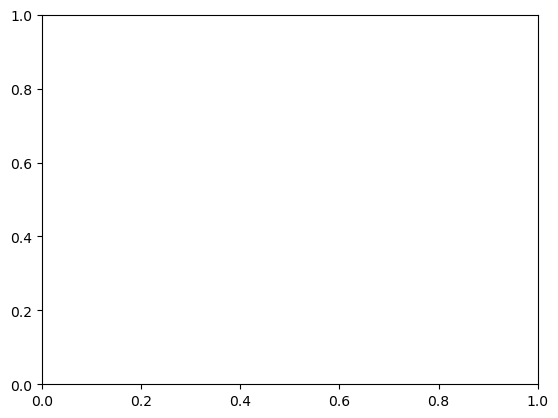

In [16]:
# check labels 
import matplotlib.pyplot as plt 
from collections import Counter 
dataset = copy.deepcopy(data)
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in dataset['labels']], axis=0)
print(non_oh)
non_oh = [int(x) for x in non_oh]
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
counts = np.bincount(non_oh)
print(counts)

x_labels = ["miscellaneous","data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
# plot histogram of labels 
fig, ax = plt.subplots();
ax.bar(range(9), counts, width=0.9, align='center');
ax.set(xticks=range(9), xlim=[-1,10]);
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=65)
ax.set_title('label distribution CSEC2017 training samples')

[205  53  26  16  80  52   5 176  18]


Text(0.5, 1.0, 'label distribution 2017 KDs')

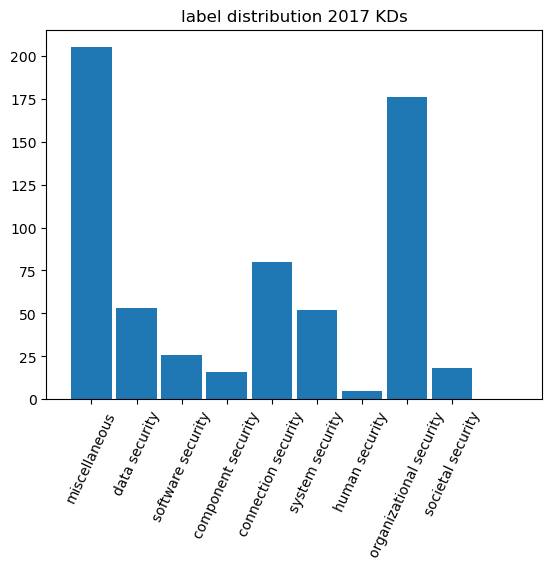

In [37]:
import matplotlib.pyplot as plt 
from collections import Counter 
dataset = copy.deepcopy(trans.data)
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in dataset['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
counts = np.bincount(non_oh)
print(counts)

x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
# plot histogram of labels 
fig, ax = plt.subplots();
ax.bar(range(9), counts, width=0.9, align='center');
ax.set(xticks=range(9), xlim=[-1,10]);
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=65)
ax.set_title('label distribution 2017 KDs')

### Evaluation

In [61]:
from sklearn.metrics import precision_recall_curve, f1_score

def find_optimal_thresholds(y_true, y_probs): 
    y_probs = sigmoid(y_probs)
    num_classes = y_true.shape[1]
    thresholds = {} 
    for i in range(num_classes): 
        precision, recall, threshold_vals = precision_recall_curve(y_true[:,i], y_probs[:,i])
        f1_scores = 2*(precision*recall) / (precision + recall + 1e-9)
        best_threshold = threshold_vals[np.argmax(f1_scores)]
        if best_threshold < 0.1: 
            best_threshold = 0.1 
        thresholds[i] = best_threshold
    return thresholds

In [71]:
labels = np.concatenate([np.array(v) for v in trans.dict1.values()])
print(labels)
predictions = np.concatenate([np.array(v) for v in trans.dict2.values()])
#print(predictions)
pred0 = sigmoid(predictions)
pred0 = (pred0 > 0.5).astype(int).reshape(-1)
metrics1 = clf_metrics.compute(predictions=pred0, references=labels.astype(int).reshape(-1))
print(metrics1)
opt_thresholds = find_optimal_thresholds(labels,predictions)
predictions = (sigmoid(predictions) >= np.array([opt_thresholds[i] for i in range(9)]))

print('opt_thresholds: ', opt_thresholds)
#predictions = (sigmoid(predictions) >= 0.5) #n
predictions = np.array(predictions, dtype=np.int32)
metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics2)
metrics2 = compute_lenient_metrics(labels.astype(int), predictions)
print(metrics2) 
conf_matrix = multilabel_confusion_matrix(labels.astype(int), predictions)

[[0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 0.]]
{'accuracy': 0.9052854938271605, 'f1': 0.5911740216486262, 'precision': 0.6228070175438597, 'recall': 0.5625990491283677}
opt_thresholds:  {0: 0.22886227, 1: 0.58548594, 2: 0.24339128, 3: 0.4045948, 4: 0.44554242, 5: 0.44493026, 6: 0.6834347, 7: 0.519353, 8: 0.7031969}
{'accuracy': 0.9070216049382716, 'f1': 0.6094003241491086, 'precision': 0.6235489220563848, 'recall': 0.595879556259905}
(64.0625, 0.6618834080717488, 0.6846011131725418, 0.640625)


In [ ]:
labels = np.concatenate([np.array(v) for v in trans2.dict1.values()])
print(labels)
predictions = np.concatenate([np.array(v) for v in trans2.dict2.values()])
#print(predictions)
pred0 = sigmoid(predictions)
pred0 = (pred0 > 0.5).astype(int).reshape(-1)
metrics1 = clf_metrics.compute(predictions=pred0, references=labels.astype(int).reshape(-1))
print(metrics1)
#opt_thresholds = find_optimal_thresholds(labels,predictions)
#print('opt_thresholds: ', opt_thresholds)
predictions = (sigmoid(predictions) >= 0.5) #np.array([opt_thresholds[i] for i in range(9)]))
predictions = np.array(predictions, dtype=np.int32)
metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics2)
conf_matrix = multilabel_confusion_matrix(labels.astype(int), predictions)

[[[294  77]
  [ 62 143]]

 [[517   6]
  [ 28  25]]

 [[537  13]
  [ 11  15]]

 [[556   4]
  [ 11   5]]

 [[468  28]
  [ 26  54]]

 [[510  14]
  [ 37  15]]

 [[569   2]
  [  4   1]]

 [[325  75]
  [ 68 108]]

 [[550   8]
  [  8  10]]]
[143  25  15   5  54  15   1 108  10]
[77  6 13  4 28 14  2 75  8]
[62 28 11 11 26 37  4 68  8]


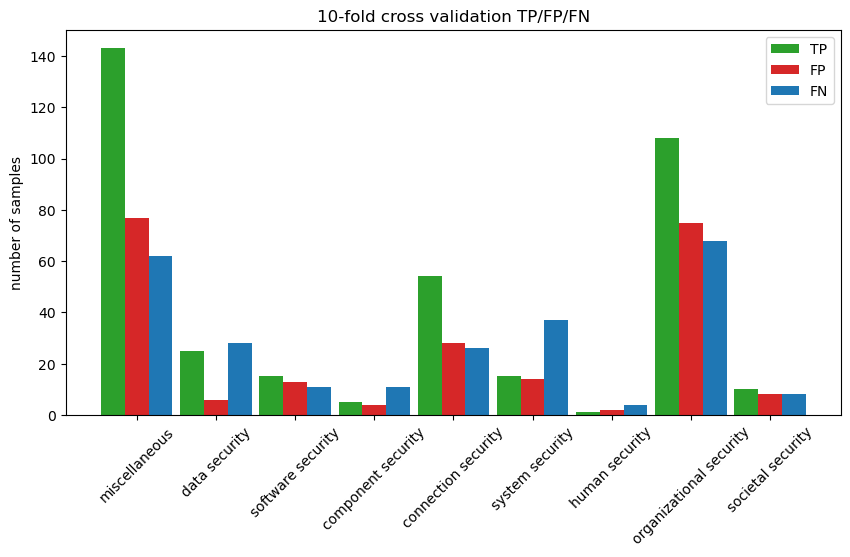

In [76]:
import matplotlib.pyplot as plt 
# turn this into a column plot. 
print(conf_matrix)
TP = conf_matrix[:,1,1]
print(TP)
FP = conf_matrix[:,0,1]
FN = conf_matrix[:,1,0]
print(FP)
print(FN)

# plot 
#x_labels = ["data security", "software security", "component security", "connection security", 
#            "system security", "human security",  "organizational security","societal security"]
x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
x = np.arange(len(x_labels))

width = 0.3 
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(x-width, TP, width,label='TP', color='tab:green')
ax.bar(x, FP, width, label= 'FP', color='tab:red')
ax.bar(x + width, FN, width, label='FN', color='tab:blue')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel('number of samples')
ax.set_title('10-fold cross validation TP/FP/FN')
ax.legend()

[[[519   4]
  [ 32  21]]

 [[542   8]
  [ 17   9]]

 [[558   2]
  [ 15   1]]

 [[469  27]
  [ 34  46]]

 [[519   5]
  [ 46   6]]

 [[567   4]
  [  5   0]]

 [[290 110]
  [ 51 125]]

 [[550   8]
  [ 11   7]]]
[ 21   9   1  46   6   0 125   7]
[  4   8   2  27   5   4 110   8]
[32 17 15 34 46  5 51 11]


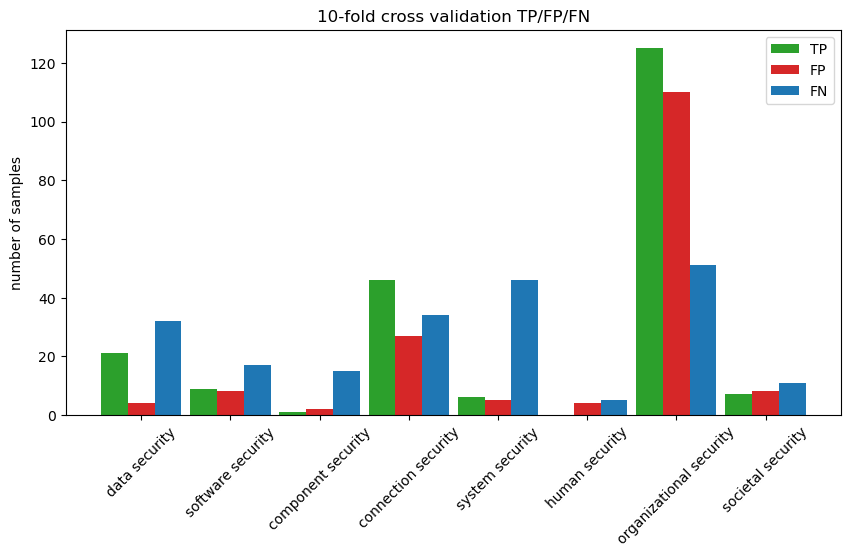

In [31]:
import matplotlib.pyplot as plt 
# turn this into a column plot. 
print(conf_matrix)
TP = conf_matrix[:,1,1]
print(TP)
FP = conf_matrix[:,0,1]
FN = conf_matrix[:,1,0]
print(FP)
print(FN)

# plot 
x_labels = ["data security", "software security", "component security", "connection security", 
           "system security", "human security",  "organizational security","societal security"]
#x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
#            "system security", "human security",  "organizational security","societal security"]
x = np.arange(len(x_labels))

width = 0.3 
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(x-width, TP, width,label='TP', color='tab:green')
ax.bar(x, FP, width, label= 'FP', color='tab:red')
ax.bar(x + width, FN, width, label='FN', color='tab:blue')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel('number of samples')
ax.set_title('10-fold cross validation TP/FP/FN')
ax.legend()

[205  53  26  16  80  52   5 176  18]


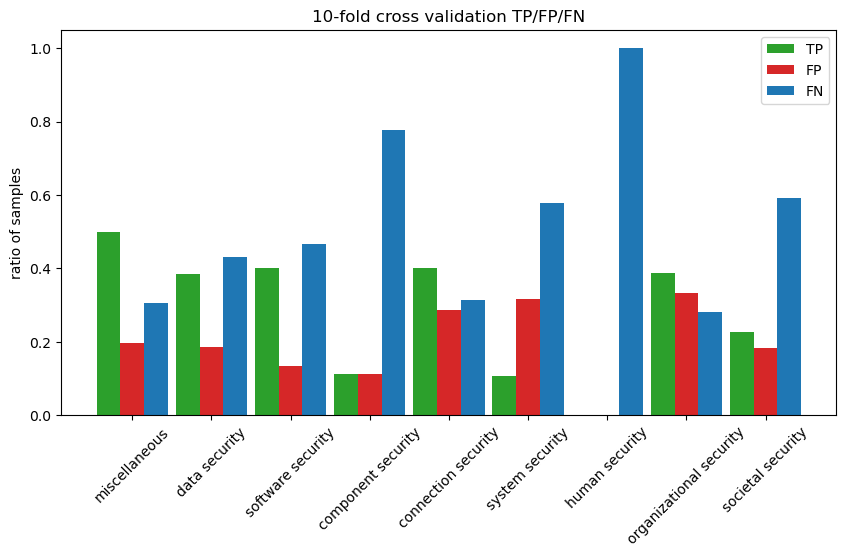

In [51]:
# same but normalized 
dataset = copy.deepcopy(trans.data)
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in dataset['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
counts = np.bincount(non_oh)
print(counts)

x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security"]
x = np.arange(len(x_labels))

width = 0.3 
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(x-width, TP/(TP+FP+FN), width,label='TP', color='tab:green')
ax.bar(x, FP/(TP+FP+FN), width, label= 'FP', color='tab:red')
ax.bar(x + width, FN/(TP+FP+FN), width, label='FN', color='tab:blue')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel('ratio of samples')
ax.set_title('10-fold cross validation TP/FP/FN')
ax.legend()

roc_auc:  [0.7450069  0.73011292 0.77664336 0.65267857 0.80927419 0.63087199
 0.59824869 0.71306818 0.77060932]
f1:  0.6094003241491086
f1:  [0.6729411764705882, 0.5952380952380953, 0.5555555555555555, 0.39999999999999997, 0.6666666666666667, 0.3703703703703704, 0.25, 0.6016713091922006, 0.5555555555555556, 0.6094003241491086]
[0.7450069028992177, 0.7301129189364697, 0.7766433566433566, 0.6526785714285714, 0.8092741935483871, 0.630871990604815, 0.5982486865148862, 0.7130681818181819, 0.7706093189964158, 0.7730111596366513]


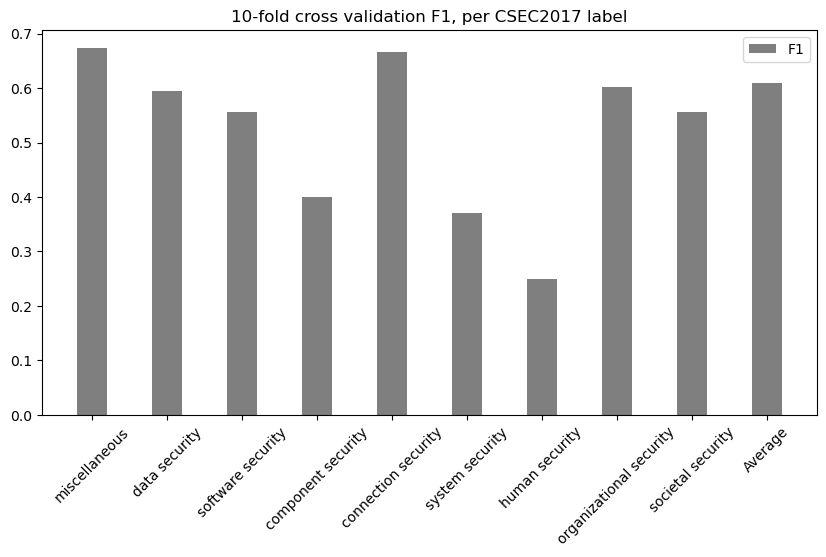

In [75]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score 
from transformers import EvalPrediction
f1s = f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average=None)

x_labels = ["miscellaneous", "data security", "software security", "component security", "connection security", 
            "system security", "human security",  "organizational security","societal security", "Average"]
#x_labels = ["data security", "software security", "component security", "connection security", 
 #           "system security", "human security",  "organizational security","societal security", "Average"]
x = np.arange(len(x_labels))

rocs = roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average=None,multi_class='ovr')
print('roc_auc: ',rocs)
#print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
 #                       average='macro')) # -> if all classes are equally important
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='micro')) # -> if all samples are equally important 
avg_f1 = f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='micro')
f1s = [x for x in f1s]
f1s.append(avg_f1)
print('f1: ',f1s)
avg_roc = roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average='micro',multi_class='ovr')
rocs = [x for x in rocs]
rocs.append(avg_roc)
print(rocs)
width = 0.4
fig, ax = plt.subplots(figsize=(10,5))

#ax.bar(x-width/2, f1s, width,label='F1', color='tab:purple')
ax.bar(x, f1s, width, label= 'F1', color='tab:grey')
#ax.bar(x + width/2, rocs, width, label='AUC-ROC', color='tab:cyan')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_title('10-fold cross validation F1, per CSEC2017 label')
ax.legend()

### Old code 

In [ ]:
# when we use the 2017 KDs as a validation dataset only. 
def train2(self, training_args, data_aug=False, balance=False, synthetic=False): 
        fold_results = [] 
        self.dict1 = {}
        self.dict2 = {}
        fold = 0 

        print(f"Training on fold {fold + 1}")
        self.val_dataset = self.data
        self.val_dataset = self.val_dataset.remove_columns(['Statement Description', '0'])
        self.init_models(self.model_name)                    # we must re-initiate the classification model for every fold
        # this is where we would add the synthetic data
        if synthetic == True: 
            dataset = datasets.load_dataset("csv",data_files={"train": "data/train_CSEC2017.csv"}, split='train')
            dataset = dataset.remove_columns('Statement Description')
            dataset = dataset.remove_columns('label')
            dataset = dataset.remove_columns(['Unnamed: 0','Unnamed: 12'])
            dataset = dataset.map(preprocess_csec) 
            dataset = dataset.remove_columns(['topics'])
            self.train_dataset = copy.deepcopy(dataset)
            
            #print(dataset2)
            # merge train_dataset with synthetic dataset. 
            #self.train_dataset = concatenate_datasets([train_dataset, dataset])
            print(self.train_dataset)

        if data_aug == True: 
            #print('true')
            output = self.train_dataset.map(data_augmentation)
            self.train_dataset = copy.deepcopy(output)

        if balance == True: 
            self.train_dataset = balance_dataset(copy.deepcopy(self.train_dataset))
        
        self.trainer = Trainer(
        model=self.model,
        args=training_args,
        train_dataset=self.train_dataset,
        eval_dataset=self.val_dataset,
        tokenizer=self.tokenizer,
        data_collator=self.data_collator,
        compute_metrics=compute_metrics,)
      
        self.trainer.train()
        metrics = self.trainer.evaluate()
        print(f"Fold {fold+1} results_before: {metrics}")
        output = self.trainer.predict(self.val_dataset)
        self.dict1[fold] = copy.deepcopy(output[1])
        self.dict2[fold] = copy.deepcopy(output[0])
            
        predictions = sigmoid(output[0])
        predictions = (predictions > 0.5).astype(int) #.reshape(-1)
        self.conf_matrix = multilabel_confusion_matrix(output[1].astype(int), predictions)
        print('confusion matrix: ',self.conf_matrix)
        fold_results.append(metrics)
        print(f"Fold {fold+1} results: {metrics}")
            
        avg_metrics = {key: np.mean([fold[key] for fold in fold_results]) for key in fold_results[0]}
        print(f"Average metrics across all folds: {avg_metrics}")
        return avg_metrics

In [19]:
clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])
pr = evaluate.load('precision')
re = evaluate.load('recall')
f1 = evaluate.load('f1') 
acc = evaluate.load('accuracy')

print('precision: ',pr.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1)))
print('recall: ',re.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1)))
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1)))
print('acc: ',acc.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1)))

metrics2 = clf_metrics.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1))
print(metrics2)

precision:  {'precision': 0.628140703517588}
recall:  {'recall': 0.5942947702060222}
f1:  {'f1': 0.6107491856677525}
acc:  {'accuracy': 0.9077932098765432}
{'accuracy': 0.9077932098765432, 'f1': 0.6107491856677525, 'precision': 0.628140703517588, 'recall': 0.5942947702060222}


In [24]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score 
from transformers import EvalPrediction
import torch 
print('accuracy: ',accuracy_score(y_pred=predictions, y_true=labels.astype(int)))
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='micro'))
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='macro'))
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average=None))
print('f1: ',f1_score(y_pred=predictions, y_true=labels.astype(int),
                        average='samples'))
print('roc_auc: ',roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average=None,multi_class='ovr'))
print('roc_auc: ',roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average='micro',multi_class='ovr')) # only implemented for ovr
print('roc_auc: ',roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average='macro',multi_class='ovo'))
print('roc_auc: ',roc_auc_score(y_score=predictions, y_true=labels.astype(int),
                        average='macro',multi_class='ovr'))

accuracy:  0.08680555555555555
f1:  0.5140913508260447
f1:  0.4145702836488372
f1:  [0.67399267 0.38613861 0.52631579 0.31372549 0.56387665 0.30833333
 0.         0.51875    0.44      ]
f1:  0.5373759920634922
roc_auc:  [0.73719019 0.762762   0.85734266 0.72589286 0.81633065 0.71168526
 0.48161121 0.59909091 0.78673835]
roc_auc:  0.8205596143049132
roc_auc:  0.7198493428235906
roc_auc:  0.7198493428235906


In [49]:
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1),
                        average='micro'))
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1),
                        average='macro'))
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1),
                        average='weighted'))
#print('f1: ',f1.compute(predictions=predictions, references=labels.astype(int),
   #                     average='samples'))
print('f1: ',f1.compute(predictions=predictions.reshape(-1), references=labels.astype(int).reshape(-1),
                        average=None))

f1:  {'f1': 0.9068287037037037}
f1:  {'f1': 0.7792462337032589}
f1:  {'f1': 0.9062136144040314}
f1:  {'f1': array([0.94706849, 0.61142397])}
